<a href="https://colab.research.google.com/github/teguhsmlnna666/Teguh-Esa-Maulanna_2411532005_ML2526/blob/main/Praktikum8/IntegrasiPCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log = LogisticRegression(max_iter=5000)
log.fit(X_train_scaled, y_train)

acc_log = accuracy_score(y_test, log.predict(X_test_scaled))
print("Logistic (No PCA):", acc_log)

Logistic (No PCA): 0.9736842105263158


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

acc_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
print("KNN (No PCA):", acc_knn)

KNN (No PCA): 0.9473684210526315


In [ ]:
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)

acc_svm = accuracy_score(y_test, svm.predict(X_test_scaled))
print("SVM (No PCA):", acc_svm)

SVM (No PCA): 0.9824561403508771


In [ ]:
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
log_pca = LogisticRegression(max_iter=5000)
log_pca.fit(X_train_pca, y_train)

acc_log_pca = accuracy_score(y_test, log_pca.predict(X_test_pca))
print("Logistic + PCA:", acc_log_pca)

Logistic + PCA: 0.9824561403508771


In [ ]:
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

acc_knn_pca = accuracy_score(y_test, knn_pca.predict(X_test_pca))
print("KNN + PCA:", acc_knn_pca)

KNN + PCA: 0.956140350877193


In [ ]:
svm_pca = SVC(kernel='rbf')
svm_pca.fit(X_train_pca, y_train)

acc_svm_pca = accuracy_score(y_test, svm_pca.predict(X_test_pca))
print("SVM + PCA:", acc_svm_pca)

SVM + PCA: 0.9649122807017544


In [ ]:
# model logistic regression
cv_log = cross_val_score(log, X_train_scaled, y_train, cv=5).mean()
cv_log_pca = cross_val_score(log_pca, X_train_pca, y_train, cv=5).mean()

print("CV Logistic:", cv_log)
print("CV Logistic + PCA:", cv_log_pca)

print()
# model knn
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5).mean()
cv_knn_pca = cross_val_score(knn_pca, X_train_pca, y_train, cv=5).mean()

print("CV KNN:", cv_knn)
print("CV KNN + PCA:", cv_knn_pca)

print()
# model svm
cv_svm = cross_val_score(svm, X_train_scaled, y_train, cv=5).mean()
cv_svm_pca = cross_val_score(svm_pca, X_train_pca, y_train, cv=5).mean()

print("CV SVM:", cv_svm)
print("CV SVM + PCA:", cv_svm_pca)

CV Logistic: 0.9736263736263737
CV Logistic + PCA: 0.9758241758241759

CV KNN: 0.9604395604395606
CV KNN + PCA: 0.9538461538461538

CV SVM: 0.9758241758241759
CV SVM + PCA: 0.9736263736263737


In [ ]:
komponen_pca = [
    ("5 Komponen", 5),
    ("10 Komponen", 10),
    ("15 Komponen", 15),
    ("90% Variance", 0.90)
]

hasil = []

for nama_pca, jumlah_komponen in komponen_pca:
    pca = PCA(n_components=jumlah_komponen)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Model Logistic Regression
    log_model = LogisticRegression(max_iter=5000)
    log_model.fit(X_train_pca, y_train)
    acc_log = accuracy_score(y_test, log_model.predict(X_test_pca))

    # Model KNN
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train_pca, y_train)
    acc_knn = accuracy_score(y_test, knn_model.predict(X_test_pca))

    # Model SVM
    svm_model = SVC(kernel='rbf')
    svm_model.fit(X_train_pca, y_train)
    acc_svm = accuracy_score(y_test, svm_model.predict(X_test_pca))

    hasil.append({
        "PCA": nama_pca,
        "Logistic": acc_log,
        "KNN": acc_knn,
        "SVM": acc_svm
    })

tabel = pd.DataFrame(hasil)
tabel

,PCA,Logistic,KNN,SVM
0,5 Komponen,0.982456,0.956140,0.964912
1,10 Komponen,0.982456,0.956140,0.964912
2,15 Komponen,0.991228,0.947368,0.982456
3,90% Variance,0.982456,0.947368,0.973684


Tugas Individu

In [ ]:
# Decision Tree + PCA
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_scaled, y_train)

acc_tree = accuracy_score(y_test, tree.predict(X_test_scaled))
print("Decision Tree (No PCA):", acc_tree)

tree_pca = DecisionTreeClassifier(random_state=42)
tree_pca.fit(X_train_pca, y_train)

acc_tree_pca = accuracy_score(y_test, tree_pca.predict(X_test_pca))
print("Decision Tree + PCA:", acc_tree_pca)

Decision Tree (No PCA): 0.9473684210526315
Decision Tree + PCA: 0.9385964912280702


In [ ]:
# Uji PCA 2 komponen saja

pca_2 = PCA(n_components=2)

X_train_pca2 = pca_2.fit_transform(X_train_scaled)
X_test_pca2 = pca_2.transform(X_test_scaled)

models = {
    "Logistic": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf'),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

hasil_pca2 = []

for nama, model in models.items():
    model.fit(X_train_pca2, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_pca2))

    hasil_pca2.append({
        "Model": nama,
        "Komponen": 2,
        "Akurasi": acc
    })

hasil_pca2_df = pd.DataFrame(hasil_pca2)
hasil_pca2_df

,Model,Komponen,Akurasi
0,Logistic,2,0.991228
1,KNN,2,0.973684
2,SVM,2,0.964912
3,Decision Tree,2,0.956140


In [ ]:
# Tambahkan GridSearchCV pada KNN
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_knn.fit(X_train_pca, y_train)

print("Parameter terbaik:", grid_knn.best_params_)
print("CV Score Terbaik:", grid_knn.best_score_)

best_knn = grid_knn.best_estimator_
acc_best_knn = accuracy_score(y_test, best_knn.predict(X_test_pca))

print("Akurasi KNN + PCA:", acc_best_knn)

Parameter terbaik: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
CV Score Terbaik: 0.9604395604395606
Akurasi KNN + PCA: 0.9473684210526315


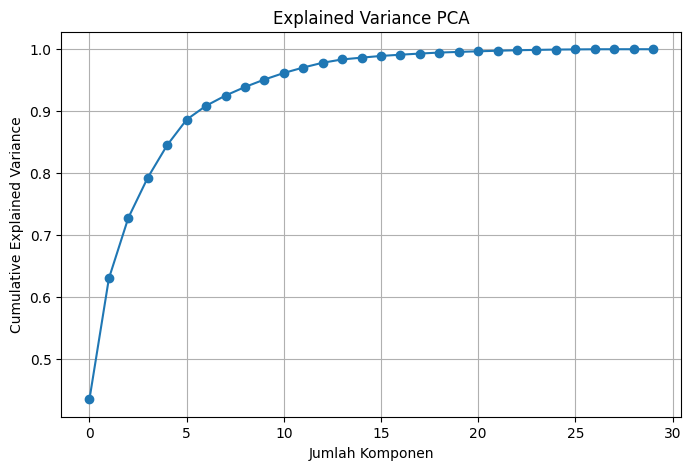

In [ ]:
# Grafik explained variance

pca_full = PCA()

pca_full.fit(X_train_scaled)

plt.figure(figsize=(8,5))
plt.plot(
    np.cumsum(pca_full.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance PCA")
plt.grid(True)

plt.show()

In [ ]:
pca_2 = PCA(n_components=2)

X_train_pca2 = pca_2.fit_transform(X_train_scaled)

print(pca_2.explained_variance_ratio_)
print(sum(pca_2.explained_variance_ratio_))

[0.43502782 0.19500007]
0.6300278846854035
